Given the roots of two binary trees p and q, return true if the trees are equivalent, otherwise return false.

Two binary trees are considered equivalent if they share the exact same structure and the nodes have the same values.

Example 1:

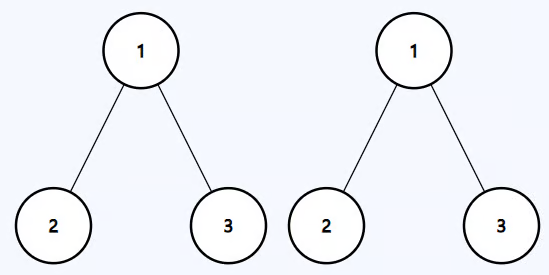

Input: p = [1,2,3], q = [1,2,3]

Output: true

Example 2:

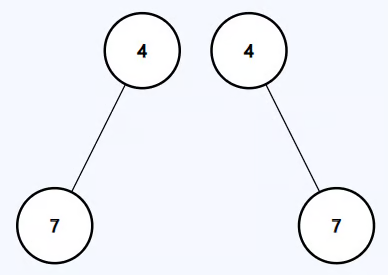

Input: p = [4,7], q = [4,null,7]

Output: false

Example 3:

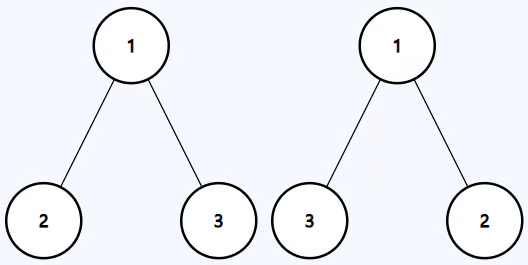

Input: p = [1,2,3], q = [1,3,2]

Output: false

In [1]:
from typing import Optional

# DFS

Intuition

Two binary trees are the same if:

Their structure is identical.

Their corresponding nodes have the same values.

So at every position:

If both nodes are null → they match.

If one is null but the other isn't → mismatch.

If both exist but values differ → mismatch.

Otherwise, compare their left subtrees and right subtrees recursively.

This is a direct structural + value-based DFS comparison.

Algorithm

If both p and q are null, return true.

If only one is null, return false.

If their values differ, return false.

Recursively compare:

p.left with q.left

p.right with q.right

Return true only if both subtree comparisons are true.

In [ ]:
# Definition for a binary tree node.
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def isSameTree(self, p: Optional[TreeNode], q: Optional[TreeNode]) -> bool:
        if not p and not q:
            return True
        if not p or not q:
            return False
        if p.val != q.val:
            return False
        return self.isSameTree(p.left, q.left) and self.isSameTree(p.right, q.right)

In [3]:
# Test cases for isSameTree

# Example 1: p = [1,2,3], q = [1,2,3] -> True
p1 = TreeNode(1, TreeNode(2), TreeNode(3))
q1 = TreeNode(1, TreeNode(2), TreeNode(3))
solution = Solution()
print(solution.isSameTree(p1, q1))  # True

# Example 2: p = [4,7], q = [4,null,7] -> False
p2 = TreeNode(4, TreeNode(7))
q2 = TreeNode(4, None, TreeNode(7))
print(solution.isSameTree(p2, q2))  # False

# Example 3: p = [1,2,3], q = [1,3,2] -> False
p3 = TreeNode(1, TreeNode(2), TreeNode(3))
q3 = TreeNode(1, TreeNode(3), TreeNode(2))
print(solution.isSameTree(p3, q3))  # False

True
False
False


# Iterative DFS

Intuition

Instead of using recursion, we can use an explicit stack to compare the two trees.

Each stack entry contains a pair of nodes—one from each tree—that should match.

For every pair:

If both are null, they match → continue.

If only one is null, or their values differ → trees are not the same.

If they match, push their children in the same order:

Left child pair

Right child pair

If we finish processing all pairs with no mismatch, the trees are identical.

Algorithm

Initialize a stack with the pair (p, q).

While the stack is not empty:

Pop a pair (node1, node2).

If both are null, continue.

If exactly one is null, return false.

If node1.val != node2.val, return false.

Push:

(node1.left, node2.left)

(node1.right, node2.right)

After the loop finishes, return true (all nodes matched).

In [ ]:
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def isSameTree(self, p: Optional[TreeNode], q: Optional[TreeNode]) -> bool:
        stack = [(p, q)]

        while stack:
            node1, node2 = stack.pop()

            if not node1 and not node2:
                continue
            if not node1 or not node2 or node1.val != node2.val:
                return False

            stack.append((node1.right, node2.right))
            stack.append((node1.left, node2.left))

        return True

# BFS

Intuition

BFS (level-order traversal) lets us compare the two trees level by level.

We maintain two queues—one for each tree. At every step, we remove a pair of nodes that should match:

If both nodes are null, they match → continue.

If only one is null, or their values differ → trees are not the same.

If they match, we push their children into their respective queues in the same order: left child first, then right child.

Algorithm

Initialize two queues:

q1 containing the root of the first tree.

q2 containing the root of the second tree.

While both queues are non-empty:

Pop one node from each queue: nodeP, nodeQ.

If both are null, continue.

If only one is null, return false.

If their values differ, return false.

Enqueue their children:

Left children of both trees.

Right children of both trees.

After BFS completes with no mismatch, return true.

In [ ]:
from collections import deque

In [ ]:
# BFS
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def isSameTree(self, p: Optional[TreeNode], q: Optional[TreeNode]) -> bool:
        q1 = deque([p])
        q2 = deque([q])

        while q1 and q2:
            for _ in range(len(q1)):
                nodeP = q1.popleft()
                nodeQ = q2.popleft()

                if nodeP is None and nodeQ is None:
                    continue
                if nodeP is None or nodeQ is None or nodeP.val != nodeQ.val:
                    return False

                q1.append(nodeP.left)
                q1.append(nodeP.right)
                q2.append(nodeQ.left)
                q2.append(nodeQ.right)

        return True